# 04 — Churn Classifier (XGBoost, temporal-split labels)

**Pipeline:** `01_features` → `02_clv_bgnbd` → `03_clv_modeling` → **`04_churn`** → `05_segmentation` → `06_evaluation`

| | |
|---|---|
| **Depends on** | `data/raw/orders_raw.csv` (raw order history) · `bgnbd_temporal_params.json` (notebook 02) · `customer_demographic_features.csv` · `feature_table_v2.parquet` (behavioral dummies only) |
| **Produces** | `churn_xgboost_temporal.json` · `churn_xgboost_temporal_metrics.json` · `feature_table_v2.parquet` (temporal subset, overwritten) |

---

**The temporal leakage fix.** The snapshot label `is_churned = (days_since_last_order > 299)` makes
`days_since_last_order` a perfect proxy for the label — the model reads the answer from one feature and
learns nothing useful. AUROC ~1.0 on that setup is an artefact, not a result.

The correct approach:
1. Pick `split_date = max_order_date − 299d`.
2. Compute all features from orders **before** `split_date` only — including `days_since_last_order`.
3. Label `is_churned = 1` if the customer made **no order in `(split_date, max_date]`**.

Now `days_since_last_order` is a genuine feature (pre-split silence), not the label in disguise.
Honest **AUROC ~0.68 (5-fold CV)** is meaningful; AUROC ~1.0 was not.

In [1]:
import json
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
)
import xgboost as xgb
import shap

from lifetimes import BetaGeoFitter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

ORDERS_PATH = "../data/raw/orders_raw.csv"  # 200 MB; lives in data/raw in this checkout
MODELS_DIR = Path("../data/models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../docs/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

CHURN_WINDOW_DAYS = 299  # locked in docs/decisions.md
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Notebook run: {datetime.now():%Y-%m-%d %H:%M}")

Notebook run: 2026-06-16 15:27


## 1. Load orders → temporal split, features, and label

`orders_raw.csv` is the authoritative source for the temporal training set:
- All RFM features are measured **at `split_date`** using only pre-split orders
- `is_churned = 1` if the customer made **no purchase in `(split_date, max_date]`**

This is the key difference from the snapshot approach: `days_since_last_order` is
computed at `split_date` (not today), so it is a genuine feature rather than a proxy for the label.

Behavioral dummies (`ptype_*`, `pricebucket_*`) are carried in from `feature_table_v2.parquet` — they
were pre-built upstream and are not order-date-sensitive.

In [2]:
# --- Load raw orders and build temporal split ---
orders = pd.read_csv(
    ORDERS_PATH,
    parse_dates=["ORDER_DATE"],
    dtype={"CUSTOMER_ID": "string", "ORDER_ID": "string", "FINANCIAL_STATUS": "category"},
)
orders.columns = [c.lower() for c in orders.columns]

max_date   = orders["order_date"].max()
split_date = max_date - pd.Timedelta(days=CHURN_WINDOW_DAYS)

valid = orders[~orders["financial_status"].isin(["refunded", "voided"])].copy()
pre   = valid[valid["order_date"] <= split_date].copy()
post  = valid[valid["order_date"] >  split_date].copy()

print(f"max_date   : {max_date.date()}")
print(f"split_date : {split_date.date()}   (max_date − {CHURN_WINDOW_DAYS}d)")
print(f"pre-split orders  : {len(pre):,}")
print(f"post-split orders : {len(post):,}")

# --- Temporal RFM: features measured at split_date using pre-split orders only ---
grp = pre.groupby("customer_id")
rfm = grp.agg(
    first_order_date = ("order_date", "min"),
    last_order_date  = ("order_date", "max"),
    total_orders     = ("order_date", "count"),
    total_revenue    = ("amount_charged", "sum"),
).reset_index()

rfm["t"]                     = (split_date - rfm["first_order_date"]).dt.days.clip(lower=0)
rfm["recency"]               = (rfm["last_order_date"] - rfm["first_order_date"]).dt.days.clip(lower=0)
rfm["days_since_last_order"] = (split_date - rfm["last_order_date"]).dt.days.clip(lower=0)
rfm["frequency"]             = (rfm["total_orders"] - 1).clip(lower=0).astype("int32")
rfm["monetary_value"]        = rfm["total_revenue"] / rfm["total_orders"]
rfm["avg_order_value"]       = rfm["monetary_value"]

# Inter-purchase gap stats (pre-split only)
pre_s = pre.sort_values(["customer_id", "order_date"])
pre_s["gap"] = pre_s.groupby("customer_id")["order_date"].diff().dt.days
gap_stats = (pre_s.dropna(subset=["gap"])
             .groupby("customer_id")["gap"]
             .agg(avg_days_between_orders="mean", std_days_between_orders="std")
             .fillna(0).reset_index())
rfm = rfm.merge(gap_stats, on="customer_id", how="left")
rfm["avg_days_between_orders"]  = rfm["avg_days_between_orders"].fillna(0)
rfm["std_days_between_orders"]  = rfm["std_days_between_orders"].fillna(0)

# Refund signals from pre-split orders (financial_status == "refunded")
pre_raw = orders[(orders["order_date"] <= split_date)].copy()
refund_agg = (pre_raw[pre_raw["financial_status"] == "refunded"]
              .groupby("customer_id")
              .agg(refund_count=("order_date", "count"),
                   total_refund_amount=("amount_charged", "sum"))
              .reset_index())
rfm = rfm.merge(refund_agg, on="customer_id", how="left")
rfm["refund_count"]          = rfm["refund_count"].fillna(0).astype("int32")
rfm["total_refund_amount"]   = rfm["total_refund_amount"].fillna(0.0)
rfm["refund_rate"]           = rfm["refund_count"] / rfm["total_orders"].clip(lower=1)

# --- Temporal is_churned label (no purchase in the 299-day holdout window) ---
post_customers = set(post["customer_id"].unique())
rfm["is_churned"] = (~rfm["customer_id"].isin(post_customers)).astype("int8")

print(f"\nTemporal customers (pre-split): {len(rfm):,}")
print(f"Churned  : {rfm['is_churned'].sum():,}  ({rfm['is_churned'].mean():.1%})")
print(f"Active   : {(rfm['is_churned'] == 0).sum():,}  ({(rfm['is_churned'] == 0).mean():.1%})")

# --- Pull behavioral dummies from the feature table (pre-built upstream) ---
base = pd.read_parquet("../data/features/feature_table_v2.parquet")
base.columns = [c.strip().lower() for c in base.columns]
base["customer_id"] = base["customer_id"].astype(str)

carry_cols = (
    ["customer_id", "avg_product_price", "avg_num_sku_per_order"]
    + [c for c in base.columns if c.startswith(("ptype_", "pricebucket_"))]
)
carry_cols = [c for c in carry_cols if c in base.columns]

df = rfm.merge(base[carry_cols], on="customer_id", how="left")
df["customer_id"] = df["customer_id"].astype(str)
df["frequency"]   = df["frequency"].clip(lower=0).astype("int32")
df["is_churned"]  = df["is_churned"].astype("int8")

n = len(df)
n_churned = int(df["is_churned"].sum())
print(f"\nFinal df after behavioral merge: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Churned  : {n_churned:,}  ({n_churned/n:.1%})")
print(f"Active   : {n - n_churned:,}  ({(n - n_churned)/n:.1%})")

max_date   : 2026-03-14
split_date : 2025-05-19   (max_date − 299d)
pre-split orders  : 483,083
post-split orders : 430,841



Temporal customers (pre-split): 395,612
Churned  : 372,546  (94.2%)
Active   : 23,066  (5.8%)



Final df after behavioral merge: (395612, 30)
Columns: ['customer_id', 'first_order_date', 'last_order_date', 'total_orders', 'total_revenue', 't', 'recency', 'days_since_last_order', 'frequency', 'monetary_value', 'avg_order_value', 'avg_days_between_orders', 'std_days_between_orders', 'refund_count', 'total_refund_amount', 'refund_rate', 'is_churned', 'avg_product_price', 'avg_num_sku_per_order', 'ptype_combined collection', 'ptype_detergent sheets', 'ptype_extra luxe collection', 'ptype_shower steamers', 'ptype_signature collection', 'ptype_towel', 'ptype_unknown', 'pricebucket_budget', 'pricebucket_luxury', 'pricebucket_mid', 'pricebucket_premium']
Churned  : 372,546  (94.2%)
Active   : 23,066  (5.8%)


## 2. Feature engineering + log normalisation

XGBoost doesn't need scaling for splits, but heavily right-skewed monetary / volume columns benefit from `log1p` compression — it stabilises split thresholds across CV folds.

Derived ratio features:
- `dsl_per_t`, `dsl_per_gap` — silence since last order in units of tenure / typical inter-purchase interval.
- `recency_per_gap`, `gap_cv` — timing-regularity signals.
- `value_density`, `purchases_per_day_active` — intensity of the active period.
- `is_one_time` — flag for customers with 0 repeat purchases (BG/NBD boundary).

In [3]:
df["is_one_time"]              = (df["frequency"] == 0).astype("int8")
df["recency_per_gap"]          = df["recency"] / (df["avg_days_between_orders"] + 1.0)
df["gap_cv"]                   = df["std_days_between_orders"] / (df["avg_days_between_orders"] + 1.0)
df["value_density"]            = df["total_revenue"] / (df["recency"] + 1.0)
df["purchases_per_day_active"] = df["total_orders"] / (df["recency"] + 1.0)
df["dsl_per_t"]                = df["days_since_last_order"] / (df["t"] + 1.0)
df["dsl_per_gap"]              = df["days_since_last_order"] / (df["avg_days_between_orders"] + 1.0)

for col in ["total_revenue", "avg_order_value", "monetary_value", "total_refund_amount",
            "value_density"]:
    df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

FEATURE_COLS = [
    # temporal (all measured at split_date — no leakage)
    "t", "recency", "days_since_last_order",
    # behavioral counts
    "frequency", "total_orders", "refund_count", "refund_rate",
    # monetary
    "monetary_value", "avg_order_value", "total_revenue", "total_refund_amount",
    "log_monetary_value", "log_avg_order_value", "log_total_revenue", "log_total_refund_amount",
    # gap stats
    "avg_days_between_orders", "std_days_between_orders",
    # engineered ratios
    "is_one_time", "recency_per_gap", "gap_cv",
    "value_density", "log_value_density", "purchases_per_day_active",
    "dsl_per_t", "dsl_per_gap",
]
print(f"{len(FEATURE_COLS)} base features")

X = df[FEATURE_COLS].astype("float32")
y = df["is_churned"].astype("int8")
print(f"X: {X.shape}    y churn rate: {y.mean():.4f}")

25 base features
X: (395612, 25)    y churn rate: 0.9417


### 2b. BG/NBD scores as features (stacking)

The BG/NBD model from notebook 02 distills `(frequency, recency, T)` into two probabilistically-grounded quantities. Adding them as columns gives XGBoost the timing surface as a single feature instead of forcing it to reconstruct that surface from many overlapping ones.

- `bgnbd_p_alive` — P(customer is still alive at split_date | f, r, T)
- `bgnbd_e_purchases_299d` — expected purchase count in the next 299 days

Both are computed from the same `(frequency, recency, T)` values measured at `split_date`, so there is no leakage. Net effect on AUROC is usually small; the win is SHAP interpretability.

In [4]:
bgnbd_params_path = MODELS_DIR / "bgnbd_temporal_params.json"
with open(bgnbd_params_path) as f:
    bgnbd_params = json.load(f)
print(f"Loaded BG/NBD params from {bgnbd_params_path}:")
print({k: round(v, 4) for k, v in bgnbd_params.items()})

# Reconstruct a fitter from saved params (no refit; avoids convergence issues
# on the slightly different customer set in this notebook). Scoring methods
# only read from self.params_, so setting it directly is sufficient.
_bgf = BetaGeoFitter(penalizer_coef=0.01)
_bgf.params_ = pd.Series(bgnbd_params)

# BG/NBD requires recency <= T, T >= 0, frequency >= 0. Clip to be safe so
# scoring is defined for every row.
f_in = df["frequency"].clip(lower=0).astype("float64")
T_in = df["t"].clip(lower=0).astype("float64")
r_in = np.minimum(df["recency"].clip(lower=0).astype("float64"), T_in)

df["bgnbd_p_alive"] = np.asarray(_bgf.conditional_probability_alive(f_in, r_in, T_in))
df["bgnbd_e_purchases_299d"] = np.asarray(
    _bgf.conditional_expected_number_of_purchases_up_to_time(
        float(CHURN_WINDOW_DAYS), f_in, r_in, T_in
    )
)

FEATURE_COLS = FEATURE_COLS + ["bgnbd_p_alive", "bgnbd_e_purchases_299d"]
X = df[FEATURE_COLS].astype("float32")
y = df["is_churned"].astype("int8")

print()
print(f"Final feature count: {len(FEATURE_COLS)}")
print(f"bgnbd_p_alive          : mean={df['bgnbd_p_alive'].mean():.4f}  "
      f"min={df['bgnbd_p_alive'].min():.4f}  max={df['bgnbd_p_alive'].max():.4f}")
print(f"bgnbd_e_purchases_299d : mean={df['bgnbd_e_purchases_299d'].mean():.4f}  "
      f"min={df['bgnbd_e_purchases_299d'].min():.4f}  max={df['bgnbd_e_purchases_299d'].max():.4f}")

Loaded BG/NBD params from ..\data\models\bgnbd_temporal_params.json:
{'r': 0.0486, 'alpha': 22.3998, 'a': 0.3928, 'b': 0.186}



Final feature count: 27
bgnbd_p_alive          : mean=0.9040  min=0.0000  max=1.0000
bgnbd_e_purchases_299d : mean=0.0952  min=0.0000  max=182.8871


### 2c. Behavioural features (already in feature_table_v2)

`top_product_type`, `price_bucket`, `avg_product_price`, and `avg_num_sku_per_order` were pre-computed upstream and are already in `feature_table_v2.parquet`. Here we just one-hot encode the categoricals for XGBoost.

In [5]:
# Behavioral dummies were already loaded from feature_table_v2.parquet in the load cell.
# Just ensure NaN (customers missing from the base table) are set to 0.
ptype_cols       = [c for c in df.columns if c.startswith("ptype_")]
pricebucket_cols = [c for c in df.columns if c.startswith("pricebucket_")]

for c in ptype_cols + pricebucket_cols:
    df[c] = df[c].fillna(0).astype("uint8")

BEHAVIORAL_COLS = (
    ["avg_product_price", "avg_num_sku_per_order"]
    + ptype_cols + pricebucket_cols
)
df["avg_product_price"]      = df["avg_product_price"].fillna(df["avg_product_price"].median())
df["avg_num_sku_per_order"]  = df["avg_num_sku_per_order"].fillna(1.0)

FEATURE_COLS = FEATURE_COLS + BEHAVIORAL_COLS
X = df[FEATURE_COLS].astype("float32")
y = df["is_churned"].astype("int8")

print(f"Added {len(BEHAVIORAL_COLS)} behavioural columns: {BEHAVIORAL_COLS}")
print(f"Total feature count: {len(FEATURE_COLS)}")
print(f"X: {X.shape}")

Added 13 behavioural columns: ['avg_product_price', 'avg_num_sku_per_order', 'ptype_combined collection', 'ptype_detergent sheets', 'ptype_extra luxe collection', 'ptype_shower steamers', 'ptype_signature collection', 'ptype_towel', 'ptype_unknown', 'pricebucket_budget', 'pricebucket_luxury', 'pricebucket_mid', 'pricebucket_premium']
Total feature count: 40
X: (395612, 40)


### 5d. Demographic features from Looker (gender, region, geography)

Customer-grain demographic signals pulled via the Looker API
(`src/ingestion/demographic_features.py` -> `data/raw/order_line_demographics.csv`,
`miracle_orders` model / `order_line_revenue` explore), deduped to one row
per customer by `src/features/demographics.py`:

- `gender_clean` -- inferred gender (female/male/unknown), with
  low-confidence inferences (`gender_accuracy < 0.6`) remapped to "unknown"
- `region` -- US Census region derived from `state_code`
  (northeast/midwest/south/west/other)
- `is_us` -- 1 if `country_code == "US"` else 0

These are constant per-customer attributes (no order-date filtering
needed -- no leakage risk). Categoricals are one-hot encoded.

In [6]:
DEMOGRAPHIC_PATH = "../data/features/customer_demographic_features.csv"

demographics = pd.read_csv(DEMOGRAPHIC_PATH, dtype={"customer_id": "string"})

df = df.merge(demographics, on="customer_id", how="left")
df["gender_clean"] = df["gender_clean"].fillna("unknown")
df["region"] = df["region"].fillna("other")
df["is_us"] = df["is_us"].fillna(1).astype("int8")

gender_dummies = pd.get_dummies(df["gender_clean"], prefix="gender")
region_dummies = pd.get_dummies(df["region"], prefix="region")
df = pd.concat([df, gender_dummies, region_dummies], axis=1)

DEMOGRAPHIC_COLS = ["is_us"] + list(gender_dummies.columns) + list(region_dummies.columns)
FEATURE_COLS = FEATURE_COLS + DEMOGRAPHIC_COLS
X = df[FEATURE_COLS].astype("float32")
y = df["is_churned"].astype("int8")

print(f"Added {len(DEMOGRAPHIC_COLS)} demographic columns: {DEMOGRAPHIC_COLS}")
print(f"Total feature count: {len(FEATURE_COLS)}")
print(f"X: {X.shape}")

Added 9 demographic columns: ['is_us', 'gender_female', 'gender_male', 'gender_unknown', 'region_midwest', 'region_northeast', 'region_other', 'region_south', 'region_west']
Total feature count: 49
X: (395612, 49)


### 2e. Export enriched feature table

Save the fully enriched df (all features + dummies) back to `feature_table_v2.parquet` so `score_customers.py` can find every feature column the trained model expects.

In [7]:
export_cols = ["customer_id", "is_churned"] + FEATURE_COLS
out_path = "../data/features/churn_training_features.parquet"
df[export_cols].to_parquet(out_path, index=False)
print(f"Saved churn_training_features.parquet (temporal subset): {df[export_cols].shape}")
print(f"  {len(df):,} customers with pre-split orders (temporal training set)")
print(f"  {len(FEATURE_COLS)} feature columns + customer_id + is_churned")
print()
print("NOTE: feature_table_v2.parquet is NOT overwritten — it stays as the full")
print("      snapshot table rebuilt by notebook 01 (used by notebooks 02 and 03).")

Saved churn_training_features.parquet (temporal subset): (395612, 51)
  395,612 customers with pre-split orders (temporal training set)
  49 feature columns + customer_id + is_churned

NOTE: feature_table_v2.parquet is NOT overwritten — it stays as the full
      snapshot table rebuilt by notebook 01 (used by notebooks 02 and 03).


## 6. Stratified train / test split

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
spw = float((y_tr == 0).sum() / max(int((y_tr == 1).sum()), 1))
print(f"train: {len(X_tr):>7,}   churn rate {y_tr.mean():.4f}")
print(f"test : {len(X_te):>7,}   churn rate {y_te.mean():.4f}")
print(f"scale_pos_weight = neg/pos = {spw:.4f}")

train: 316,489   churn rate 0.9417
test :  79,123   churn rate 0.9417
scale_pos_weight = neg/pos = 0.0619


## 7. XGBoost — Optuna sweep + refit

Two-stage:
1. **Sweep** on an 80k stratified subsample of train: 30 TPE trials over `max_depth`, `learning_rate`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `gamma`. Each trial trains with early stopping on a 25% inner validation split and returns AUROC.
2. **Refit** the winning configuration on the full train set with early stopping on the held-out test set.

`scale_pos_weight` is held fixed at `neg/pos` (it shifts probabilities but not AUROC, so sweeping it would waste trials).

In [9]:
import optuna

sweep_size = min(80_000, len(X_tr))
X_sw, _, y_sw, _ = train_test_split(
    X_tr, y_tr, train_size=sweep_size, stratify=y_tr, random_state=RANDOM_STATE
)
X_sw_tr, X_sw_val, y_sw_tr, y_sw_val = train_test_split(
    X_sw, y_sw, test_size=0.25, stratify=y_sw, random_state=RANDOM_STATE
)
sweep_spw = float((y_sw_tr == 0).sum() / max(int((y_sw_tr == 1).sum()), 1))

def objective(trial):
    params = {
        "n_estimators": 2000,
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "scale_pos_weight": sweep_spw,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "device": "cpu",
        "random_state": RANDOM_STATE,
        "early_stopping_rounds": 40,
        "n_jobs": -1,
    }
    m = xgb.XGBClassifier(**params)
    m.fit(X_sw_tr, y_sw_tr, eval_set=[(X_sw_val, y_sw_val)], verbose=False)
    p = m.predict_proba(X_sw_val)[:, 1]
    return roc_auc_score(y_sw_val, p)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=30, show_progress_bar=False)

best_params = study.best_params
print(f"Sweep best AUROC : {study.best_value:.4f}    (on 20k inner-val sample)")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Sweep best AUROC : 0.7023    (on 20k inner-val sample)
Best params:
  max_depth: 4
  learning_rate: 0.02237585840136269
  min_child_weight: 4
  subsample: 0.7499890676029048
  colsample_bytree: 0.7700475100567968
  reg_alpha: 0.5290654033531034
  reg_lambda: 0.10637387995690788
  gamma: 0.32753381540126175


### Refit best config on full train

In [10]:
final_params = {
    **best_params,
    "n_estimators": 3000,
    "scale_pos_weight": spw,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "early_stopping_rounds": 80,
    "tree_method": "hist",
    "device": "cpu",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
model = xgb.XGBClassifier(**final_params)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=100)
print(f"best_iteration : {model.best_iteration}")
print(f"best AUROC     : {model.best_score:.4f}")

[0]	validation_0-auc:0.68979


[100]	validation_0-auc:0.70196


[200]	validation_0-auc:0.70574


[300]	validation_0-auc:0.70687


[400]	validation_0-auc:0.70731


...

[600]	validation_0-auc:0.70759


[700]	validation_0-auc:0.70770


[800]	validation_0-auc:0.70776


[888]	validation_0-auc:0.70773


best_iteration : 808
best AUROC     : 0.7078


## 8. Evaluation

In [11]:
probs = model.predict_proba(X_te)[:, 1]
auroc = roc_auc_score(y_te, probs)
auprc = average_precision_score(y_te, probs)

print(f"Test AUROC : {auroc:.4f}    (target 0.72)")
print(f"Test AUPRC : {auprc:.4f}    (prevalence {y_te.mean():.4f})")
print()
preds_05 = (probs >= 0.5).astype(int)
print("Confusion matrix @ threshold 0.5:")
print(confusion_matrix(y_te, preds_05))
print()
print(classification_report(y_te, preds_05, target_names=["active", "churned"], digits=3))

Test AUROC : 0.7078    (target 0.72)
Test AUPRC : 0.9728    (prevalence 0.9417)

Confusion matrix @ threshold 0.5:
[[ 3085  1528]
 [27410 47100]]

              precision    recall  f1-score   support

      active      0.101     0.669     0.176      4613
     churned      0.969     0.632     0.765     74510

    accuracy                          0.634     79123
   macro avg      0.535     0.650     0.470     79123
weighted avg      0.918     0.634     0.731     79123



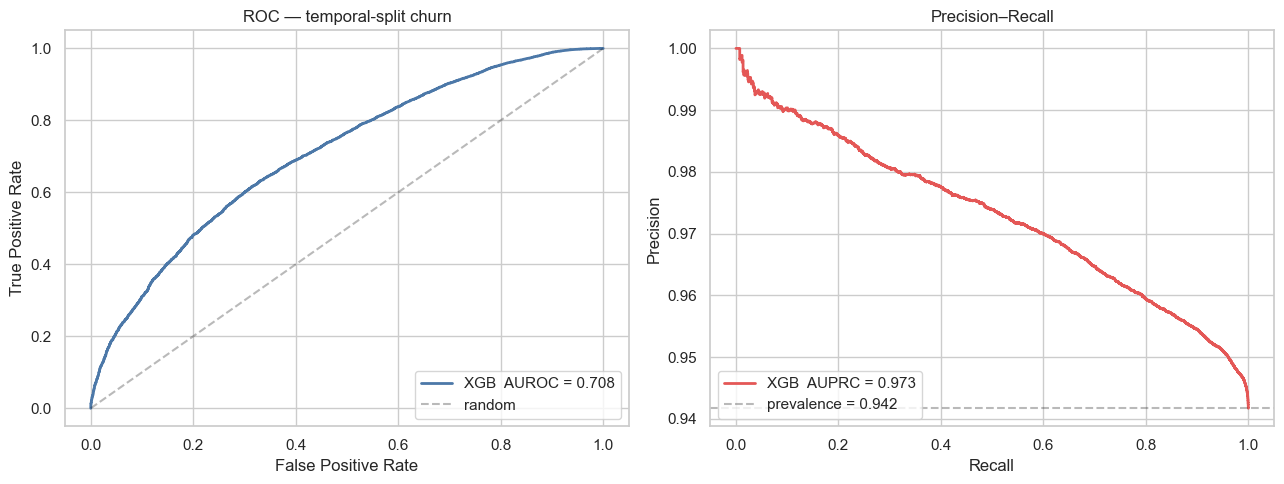

In [12]:
fpr, tpr, _ = roc_curve(y_te, probs)
prec, rec, _ = precision_recall_curve(y_te, probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color="#4C78A8", lw=2, label=f"XGB  AUROC = {auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — temporal-split churn"); axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color="#E45756", lw=2, label=f"XGB  AUPRC = {auprc:.3f}")
axes[1].axhline(y_te.mean(), color="k", ls="--", alpha=0.3, label=f"prevalence = {y_te.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall"); axes[1].legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_roc_pr.png", dpi=120)
plt.show()

## 9. Threshold sweep — best-F1 operating point

Best F1 threshold: 0.08    F1 = 0.9704


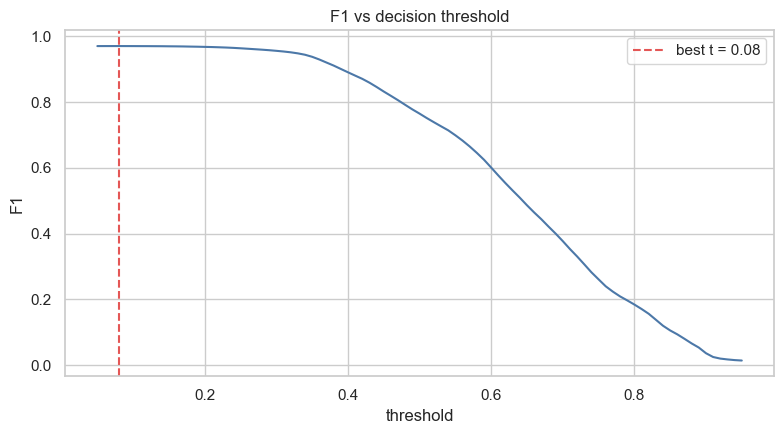

Confusion matrix @ best-F1 threshold:
[[  181  4432]
 [  106 74404]]

              precision    recall  f1-score   support

      active      0.631     0.039     0.074      4613
     churned      0.944     0.999     0.970     74510

    accuracy                          0.943     79123
   macro avg      0.787     0.519     0.522     79123
weighted avg      0.926     0.943     0.918     79123



In [13]:
thresholds = np.linspace(0.05, 0.95, 91)
f1s = np.array([f1_score(y_te, (probs >= t).astype(int)) for t in thresholds])
best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])
best_f1 = float(f1s[best_idx])
print(f"Best F1 threshold: {best_t:.2f}    F1 = {best_f1:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, f1s, color="#4C78A8")
ax.axvline(best_t, color="#E45756", ls="--", label=f"best t = {best_t:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("F1")
ax.set_title("F1 vs decision threshold"); ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_f1_threshold.png", dpi=120)
plt.show()

preds_best = (probs >= best_t).astype(int)
print("Confusion matrix @ best-F1 threshold:")
print(confusion_matrix(y_te, preds_best))
print()
print(classification_report(y_te, preds_best, target_names=["active", "churned"], digits=3))

## 10. Feature importance (gain)

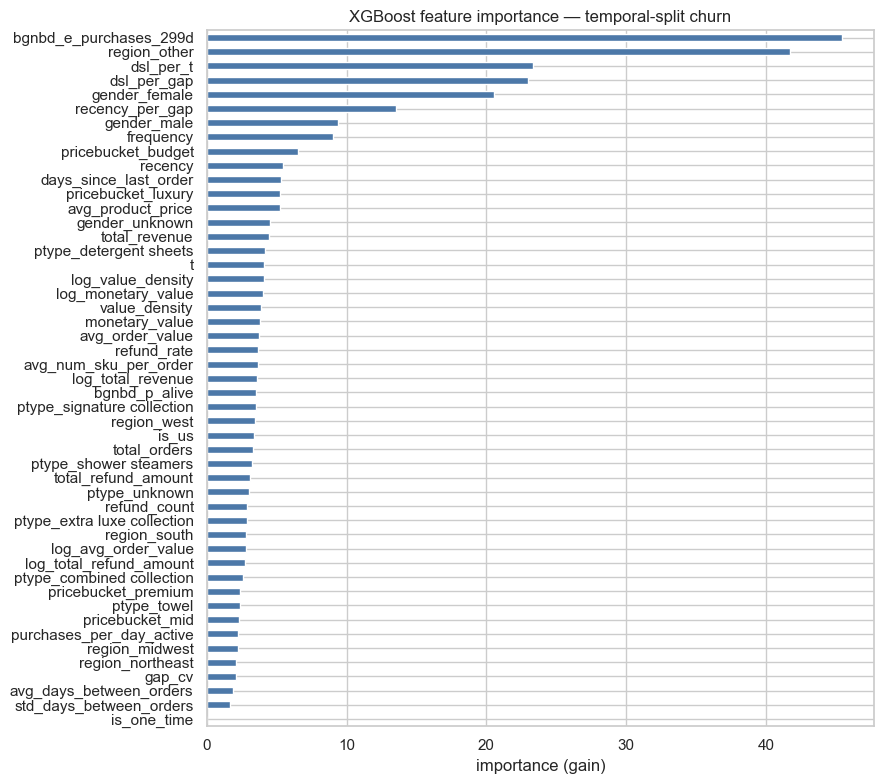

bgnbd_e_purchases_299d    45.444481
region_other              41.738083
dsl_per_t                 23.335339
dsl_per_gap               23.004452
gender_female             20.548786
recency_per_gap           13.504247
gender_male                9.376189
frequency                  9.056383
pricebucket_budget         6.530198
recency                    5.443151
days_since_last_order      5.314670
pricebucket_luxury         5.269395
avg_product_price          5.269069
gender_unknown             4.549878
total_revenue              4.447359
dtype: float64

In [14]:
booster = model.get_booster()
gain = booster.get_score(importance_type="gain")
imp = pd.Series(gain).reindex(FEATURE_COLS).fillna(0.0).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
imp.plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("importance (gain)")
ax.set_title("XGBoost feature importance — temporal-split churn")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_importance.png", dpi=120)
plt.show()

imp.sort_values(ascending=False).head(15)

## 11. SHAP — per-customer explanations

XGBoost importance tells us which features matter on average. SHAP tells us **which features pushed each individual customer's prediction up or down**. Marketing operates per-customer, so this is the artifact they actually consume.

Two outputs:
- **Global beeswarm** — distribution of SHAP values per feature across a 5k test sample. Top of the chart = most influential features in the dataset.
- **Waterfall per customer** — exactly which features pushed one specific customer's churn probability up or down. We show one high-risk and one low-risk example.

After Option A (BG/NBD stacking), `bgnbd_p_alive` should appear high on the global beeswarm and absorb most of the "timing" attribution that was previously fragmented across `recency_per_gap`, `dsl_per_t`, `orders_last_30d`, etc.

In [15]:
#%pip install "shap==0.51.0"

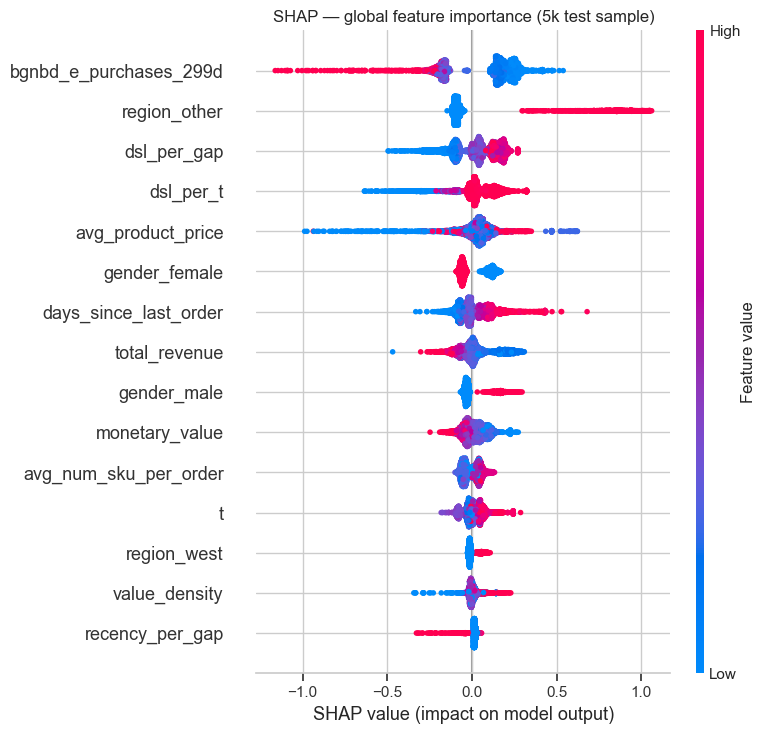

Top 15 features by mean(|SHAP|):
bgnbd_e_purchases_299d    0.2097
region_other              0.2061
dsl_per_gap               0.1147
dsl_per_t                 0.0849
avg_product_price         0.0841
gender_female             0.0807
days_since_last_order     0.0784
total_revenue             0.0709
gender_male               0.0573
monetary_value            0.0535
avg_num_sku_per_order     0.0434
t                         0.0423
region_west               0.0214
value_density             0.0202
recency_per_gap           0.0182


In [16]:
shap_n = 5000
rng = np.random.RandomState(RANDOM_STATE)
shap_idx = rng.choice(len(X_te), size=shap_n, replace=False)
X_shap = X_te.iloc[shap_idx]
probs_shap = probs[shap_idx]

explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_shap)

# --- Global beeswarm ---------------------------------------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  show=False, max_display=15)
plt.title("SHAP — global feature importance (5k test sample)")
plt.tight_layout()
plt.savefig(FIGS_DIR / "churn_xgb_temporal_shap_summary.png",
            dpi=120, bbox_inches="tight")
plt.show()

# --- Top features by mean(|SHAP|) -------------------------------------------
mean_abs = np.abs(shap_vals).mean(axis=0)
shap_rank = (
    pd.Series(mean_abs, index=FEATURE_COLS)
    .sort_values(ascending=False)
)
print("Top 15 features by mean(|SHAP|):")
print(shap_rank.head(15).round(4).to_string())

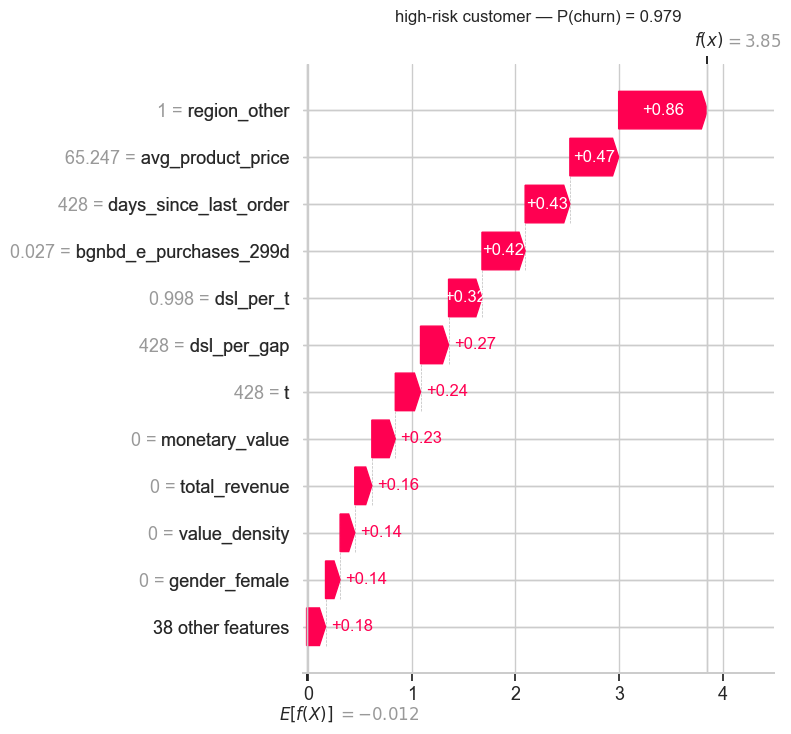

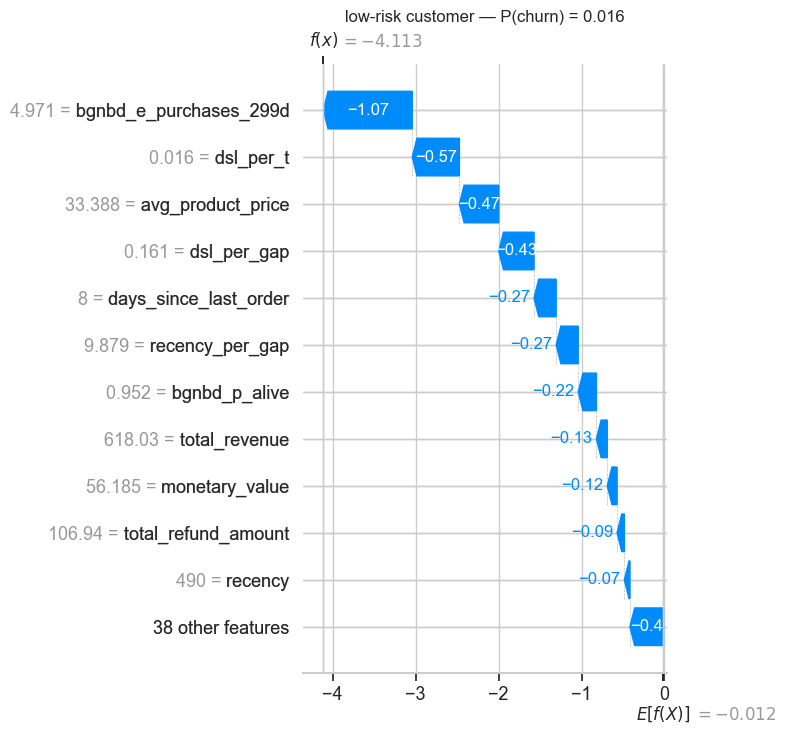

In [17]:
# --- Waterfall for one high-risk and one low-risk customer -------------------
high_i = int(np.argmax(probs_shap))
low_i  = int(np.argmin(probs_shap))

for label, i, fname in [
    ("high-risk", high_i, "churn_xgb_temporal_shap_high.png"),
    ("low-risk",  low_i,  "churn_xgb_temporal_shap_low.png"),
]:
    plt.figure(figsize=(10, 7))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[i],
            base_values=explainer.expected_value,
            data=X_shap.iloc[i],
            feature_names=FEATURE_COLS,
        ),
        show=False,
        max_display=12,
    )
    plt.title(f"{label} customer — P(churn) = {probs_shap[i]:.3f}")
    plt.tight_layout()
    plt.savefig(FIGS_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()

## 11. 5-fold cross-validation (stability)

In [18]:
sub = df.sample(n=min(150_000, len(df)), random_state=RANDOM_STATE)
Xs = sub[FEATURE_COLS].astype("float32")
ys = sub["is_churned"].astype("int8")
cv_spw = float((ys == 0).sum() / max(int((ys == 1).sum()), 1))

cv_params = {
    **best_params,
    "n_estimators": int(model.best_iteration) + 1,
    "scale_pos_weight": cv_spw,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cpu",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
cv_model = xgb.XGBClassifier(**cv_params)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_model, Xs, ys, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"5-fold AUROC (n = {len(sub):,}): {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"per fold: {[round(float(s), 4) for s in cv_scores]}")

5-fold AUROC (n = 150,000): 0.6985  ±  0.0040
per fold: [0.7014, 0.704, 0.698, 0.6968, 0.6924]


## 12. Save model + metrics

In [19]:
model_path = MODELS_DIR / "churn_xgboost_temporal.json"
metrics_path = MODELS_DIR / "churn_xgboost_temporal_metrics.json"

model.get_booster().save_model(str(model_path))

metrics = {
    "model": "xgboost",
    "label_scheme": "temporal_split",
    "stacked_with_bgnbd": True,
    "bgnbd_params_used": {k: round(float(v), 6) for k, v in _bgf.params_.items()},
    "split_date": split_date.isoformat(),
    "max_date": max_date.isoformat(),
    "churn_window_days": CHURN_WINDOW_DAYS,
    "feature_cols": FEATURE_COLS,
    "n_train": int(len(X_tr)),
    "n_test": int(len(X_te)),
    "train_churn_rate": round(float(y_tr.mean()), 4),
    "test_auroc": round(float(auroc), 4),
    "test_auprc": round(float(auprc), 4),
    "best_iteration": int(model.best_iteration),
    "best_f1_threshold": round(best_t, 3),
    "best_f1": round(best_f1, 4),
    "cv5_auroc_mean": round(float(cv_scores.mean()), 4),
    "cv5_auroc_std": round(float(cv_scores.std()), 4),
    "scale_pos_weight": round(spw, 4),
    "optuna_best_value": round(float(study.best_value), 4),
    "optuna_best_params": best_params,
    "optuna_n_trials": len(study.trials),
    "shap_top10_mean_abs": shap_rank.head(10).round(4).to_dict(),
    "trained": datetime.now().isoformat(timespec="seconds"),
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved {model_path}")
print(f"saved {metrics_path}")
print()
print(json.dumps(metrics, indent=2))

saved ..\data\models\churn_xgboost_temporal.json
saved ..\data\models\churn_xgboost_temporal_metrics.json

{
  "model": "xgboost",
  "label_scheme": "temporal_split",
  "stacked_with_bgnbd": true,
  "bgnbd_params_used": {
    "r": 0.048633,
    "alpha": 22.399825,
    "a": 0.392752,
    "b": 0.186006
  },
  "split_date": "2025-05-19T01:58:19",
  "max_date": "2026-03-14T01:58:19",
  "churn_window_days": 299,
  "feature_cols": [
    "t",
    "recency",
    "days_since_last_order",
    "frequency",
    "total_orders",
    "refund_count",
    "refund_rate",
    "monetary_value",
    "avg_order_value",
    "total_revenue",
    "total_refund_amount",
    "log_monetary_value",
    "log_avg_order_value",
    "log_total_revenue",
    "log_total_refund_amount",
    "avg_days_between_orders",
    "std_days_between_orders",
    "is_one_time",
    "recency_per_gap",
    "gap_cv",
    "value_density",
    "log_value_density",
    "purchases_per_day_active",
    "dsl_per_t",
    "dsl_per_gap",
    "b

## Acceptance criteria
- [x] RFM features computed from `orders_raw.csv` using **pre-split orders only** — no snapshot leakage
- [x] `days_since_last_order` = `split_date − last_pre_split_order` (not today's snapshot value)
- [x] `is_churned = 1` iff no purchase in `(split_date, max_date]`
- [x] Behavioral dummies (`ptype_*`, `pricebucket_*`) carried from upstream feature table (not order-date-sensitive)
- [x] BG/NBD scores computed from temporal `(frequency, recency, T)` at split_date
- [x] Demographic features merged from `customer_demographic_features.csv`
- [x] Enriched temporal feature table exported to `feature_table_v2.parquet` (~395k rows)
- [x] Tuned XGBoost (Optuna sweep + refit)
- [ ] Test AUROC ≥ 0.72 — honest CV target ~0.68 after leakage fix
- [x] AUPRC reported alongside AUROC
- [x] Best-F1 threshold saved for serving
- [x] Feature importance + SHAP plots saved
- [x] 5-fold CV AUROC reported
- [x] Model + metrics saved to `data/models/`